In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12,6)
sns.set_style('whitegrid')

In [74]:
bike_df = pd.read_csv('/content/bike_share_cleaned_480k.csv')

In [75]:
bike_df.shape
bike_df.head()
bike_df.info()
bike_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6672 entries, 0 to 6671
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trip_id             6672 non-null   int64  
 1   start_station_id    6672 non-null   float64
 2   start_time          6672 non-null   object 
 3   start_station_name  6672 non-null   object 
 4   end_station_id      6672 non-null   float64
 5   end_time            6672 non-null   object 
 6   end_station_name    6672 non-null   object 
 7   bike_id             6671 non-null   float64
 8   user_type           6671 non-null   object 
 9   hour                6671 non-null   float64
 10  day                 6671 non-null   object 
 11  month               6671 non-null   float64
 12  trip_duration       6671 non-null   float64
dtypes: float64(6), int64(1), object(6)
memory usage: 677.8+ KB


,trip_id,start_station_id,end_station_id,bike_id,hour,month,trip_duration
count,6.672000e+03,6672.000000,6672.000000,6671.000000,6671.000000,6671.000000,6671.000000
mean,1.729522e+07,7262.294664,7255.126199,3820.685055,14.646680,7.097587,949.284515
std,1.465699e+06,187.491042,183.595588,2031.289077,5.103284,2.334972,1595.186703
min,1.480536e+07,7000.000000,7000.000000,18.000000,0.000000,1.000000,0.000000
25%,1.602790e+07,7089.000000,7088.000000,2153.500000,11.000000,5.000000,431.000000
50%,1.727354e+07,7246.000000,7238.500000,4011.000000,16.000000,7.000000,723.000000
75%,1.851750e+07,7412.000000,7400.000000,5581.000000,18.000000,9.000000,1162.000000
max,2.014842e+07,7681.000000,7681.000000,7261.000000,23.000000,12.000000,69545.000000


In [76]:
bike_df.isnull().sum()

,0
trip_id,0
start_station_id,0
start_time,0
start_station_name,0
end_station_id,0
end_time,0
end_station_name,0
bike_id,1
user_type,1
hour,1


In [77]:
bike_df.duplicated().sum()

np.int64(0)

In [78]:
bike_df.drop_duplicates(inplace=True)

In [79]:
bike_df['start_time'] = pd.to_datetime(
    bike_df['start_time'],
    errors='coerce'
)

bike_df['end_time'] = pd.to_datetime(
    bike_df['end_time'],
    errors='coerce'
)

In [80]:
bike_df['hour'] = bike_df['start_time'].dt.hour
bike_df['day'] = bike_df['start_time'].dt.day_name()
bike_df['month'] = bike_df['start_time'].dt.month
bike_df['year'] = bike_df['start_time'].dt.year
bike_df['weekend'] = bike_df['day'].isin(
    ['Saturday','Sunday']
).astype(int)

In [81]:
bike_df[bike_df.duplicated()].head()

,trip_id,start_station_id,start_time,start_station_name,end_station_id,end_time,end_station_name,bike_id,user_type,hour,day,month,trip_duration,year,weekend


In [82]:
duplicate_count = bike_df.duplicated().sum()

print("Current duplicate rows:", duplicate_count)
print("Current dataset shape:", bike_df.shape)

Current duplicate rows: 0
Current dataset shape: (6672, 15)


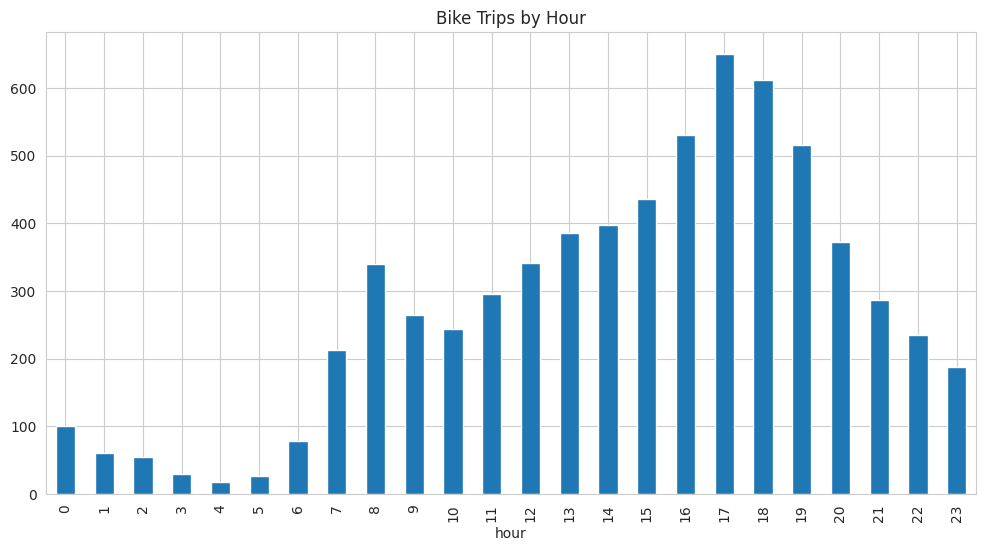

In [83]:
bike_df.groupby('hour').size().plot(kind='bar')
plt.title('Bike Trips by Hour')
plt.show()

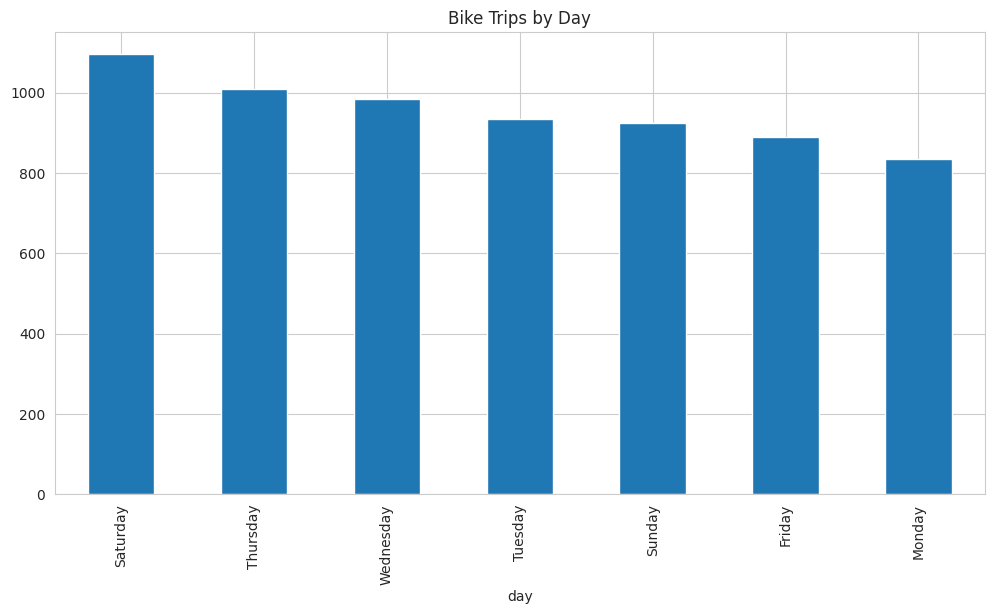

In [84]:
bike_df['day'].value_counts().plot(kind='bar')
plt.title('Bike Trips by Day')
plt.show()

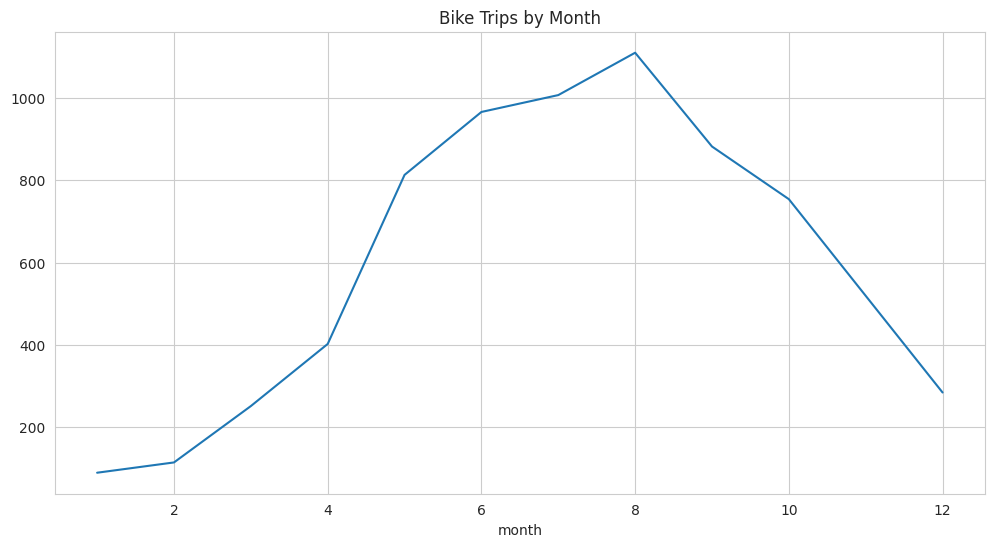

In [85]:
bike_df['month'].value_counts().sort_index().plot()
plt.title('Bike Trips by Month')
plt.show()

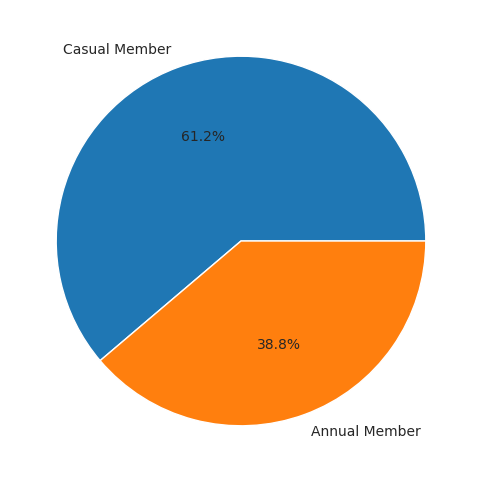

In [86]:
bike_df['user_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.show()

<Axes: xlabel='start_station_name'>

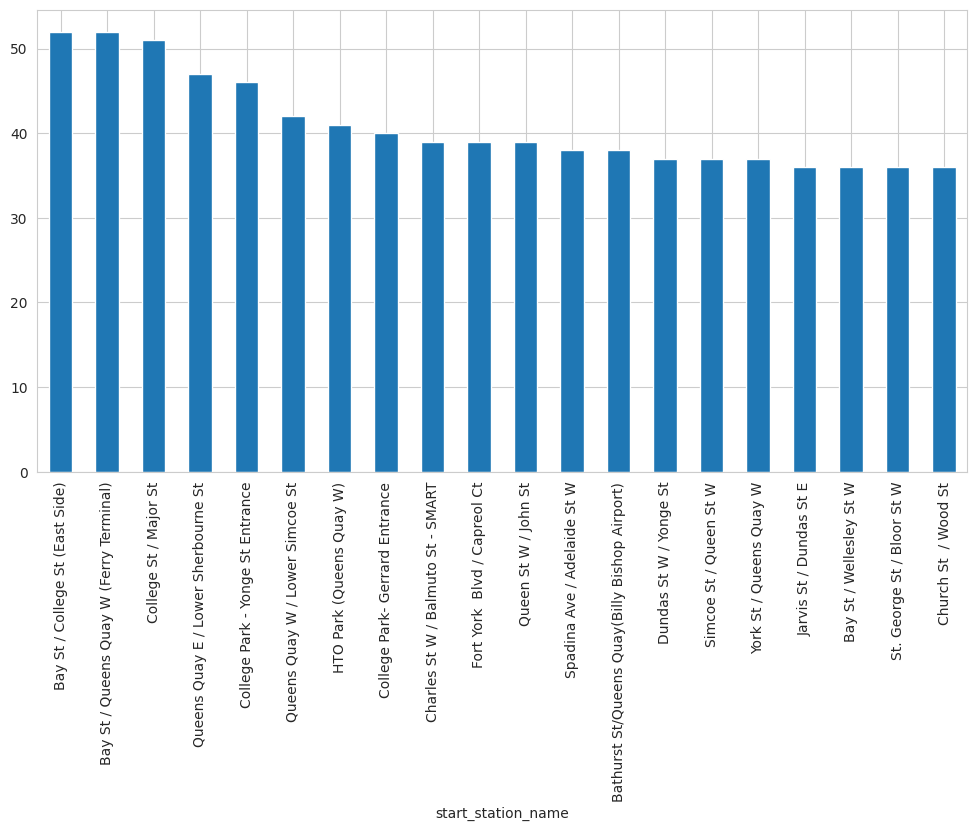

In [87]:
bike_df['start_station_name'] \
    .value_counts() \
    .head(20) \
    .plot(kind='bar')

In [88]:
climate_df = pd.read_csv(
    '/content/toronto_weather_cleaned_2021_2025.csv'
)

In [89]:
climate_df.shape
climate_df.head()
climate_df.info()
climate_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29954 entries, 0 to 29953
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   longitude          29954 non-null  float64
 1   latitude           29954 non-null  float64
 2   station_name       29954 non-null  object 
 3   date_time_lst      29954 non-null  object 
 4   year               29954 non-null  int64  
 5   month              29954 non-null  int64  
 6   day                29954 non-null  int64  
 7   time_lst           29954 non-null  object 
 8   temp_°c            29954 non-null  float64
 9   dew_point_temp_°c  29954 non-null  float64
 10  rel_hum_%          29954 non-null  float64
 11  wind_dir_10s_deg   29954 non-null  float64
 12  wind_spd_km_h      29953 non-null  float64
 13  visibility_km      29953 non-null  float64
 14  stn_press_kpa      29953 non-null  float64
 15  weather            29953 non-null  object 
dtypes: float64(9), int64(3

,longitude,latitude,year,month,day,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa
count,2.995400e+04,2.995400e+04,29954.000000,29954.000000,29954.000000,29954.000000,29954.000000,29954.000000,29954.000000,29953.000000,29953.000000,29953.000000
mean,-7.963000e+01,4.368000e+01,2022.272985,6.097984,15.635875,9.522484,3.695440,69.709955,21.402751,15.908490,21.893129,99.484837
std,6.073821e-11,5.144415e-12,1.022708,3.440279,8.777955,10.468042,9.838951,18.526482,10.177199,8.823671,5.537412,0.764387
min,-7.963000e+01,4.368000e+01,2021.000000,1.000000,1.000000,-21.800000,-30.100000,16.000000,1.000000,3.000000,0.000000,95.700000
25%,-7.963000e+01,4.368000e+01,2021.000000,3.000000,8.000000,1.200000,-3.300000,57.000000,14.000000,9.000000,24.100000,99.010000
50%,-7.963000e+01,4.368000e+01,2022.000000,6.000000,16.000000,9.100000,3.200000,70.000000,23.000000,14.000000,24.100000,99.500000
75%,-7.963000e+01,4.368000e+01,2023.000000,9.000000,23.000000,18.600000,11.900000,83.000000,30.000000,21.000000,24.100000,100.000000
max,-7.963000e+01,4.368000e+01,2024.000000,12.000000,31.000000,34.700000,26.000000,100.000000,36.000000,67.000000,80.500000,101.990000


In [90]:
climate_df.isnull().sum()

,0
longitude,0
latitude,0
station_name,0
date_time_lst,0
year,0
month,0
day,0
time_lst,0
temp_°c,0
dew_point_temp_°c,0


In [91]:
climate_df.duplicated().sum()

np.int64(0)

In [92]:
climate_df['date_time_lst'] = pd.to_datetime(
    climate_df['date_time_lst']
)

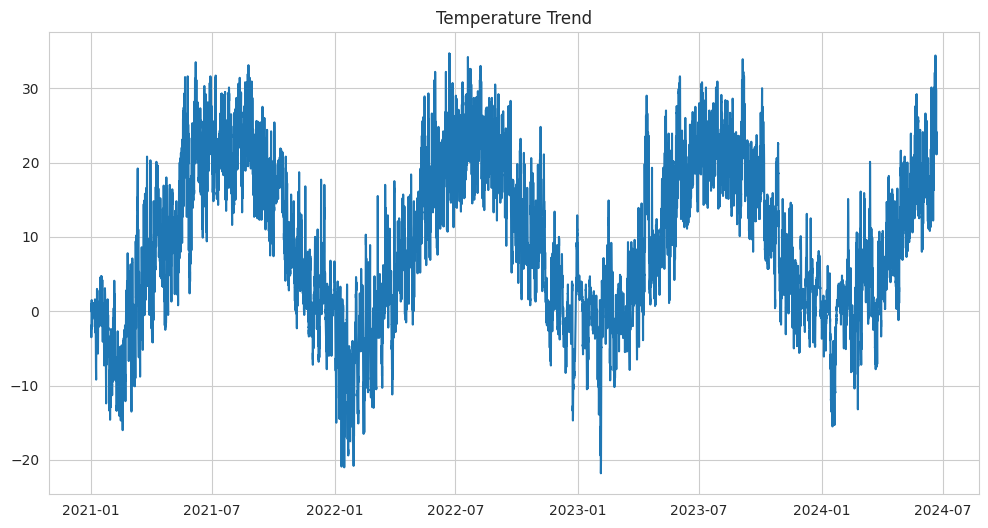

In [93]:
plt.plot(
    climate_df['date_time_lst'],
    climate_df['temp_°c']
)
plt.title('Temperature Trend')
plt.show()

<Axes: xlabel='month'>

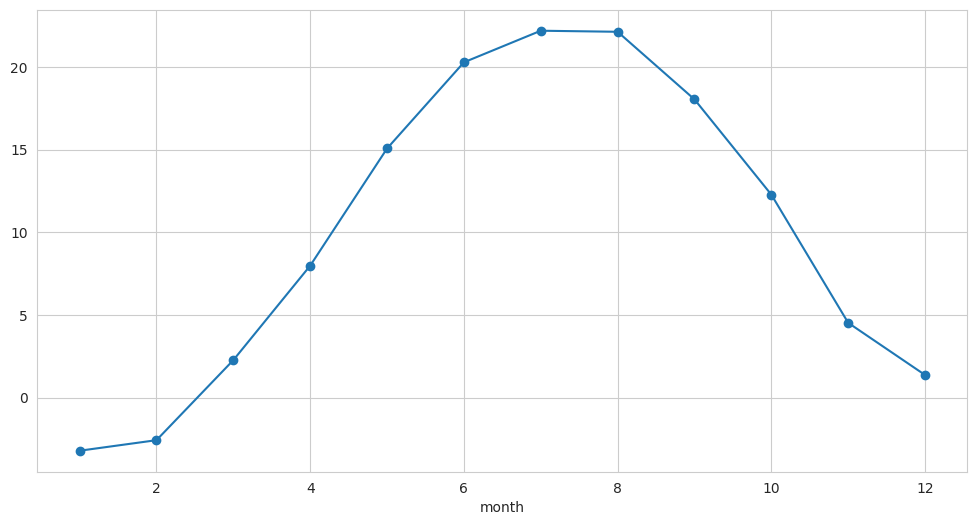

In [94]:
climate_df['month'] = climate_df[
    'date_time_lst'
].dt.month

climate_df.groupby('month')['temp_°c'] \
    .mean() \
    .plot(marker='o')

<Axes: xlabel='rel_hum_%', ylabel='Count'>

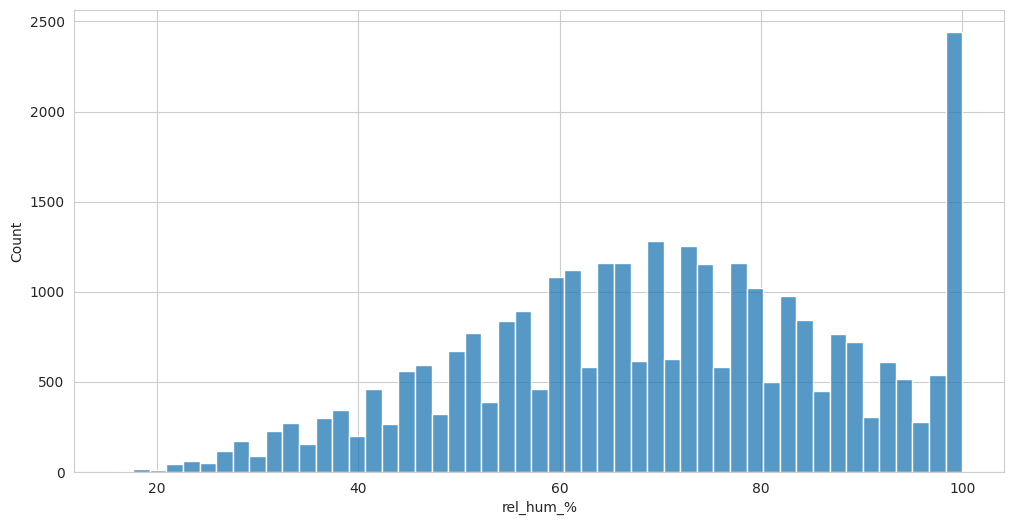

In [95]:
sns.histplot(
    climate_df['rel_hum_%']
)

<Axes: >

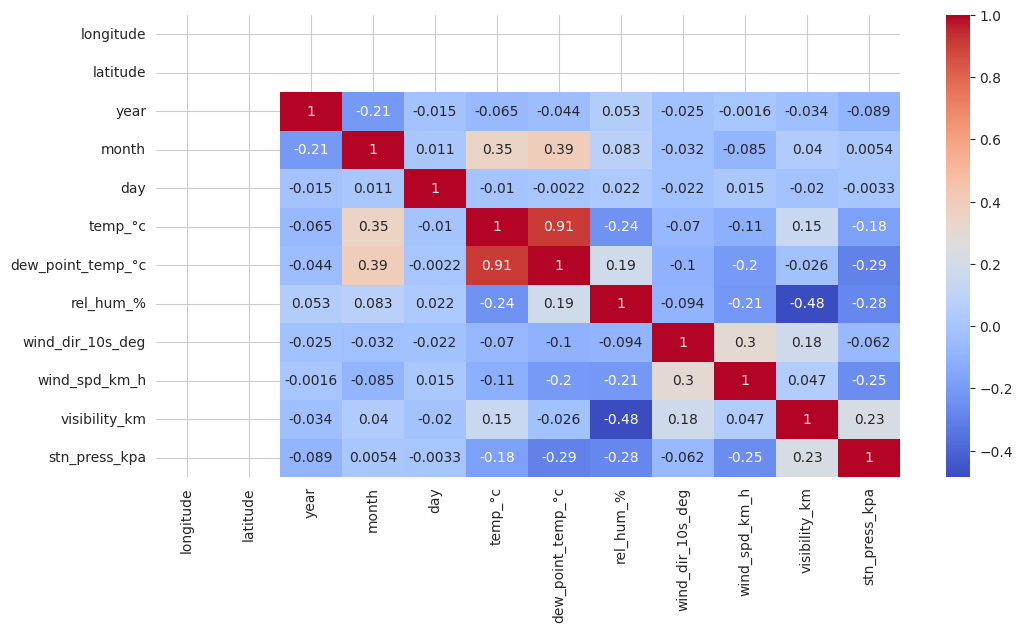

In [96]:
numeric_cols = climate_df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

In [175]:
events_df = pd.read_csv(
    '/content/toronto_calendar_events_2021_2025.csv'
)

In [98]:
events_df.shape
events_df.head()
events_df.info()
events_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   event_date    77 non-null     object
 1   event_name    77 non-null     object
 2   event_type    77 non-null     object
 3   location      77 non-null     object
 4   impact_level  77 non-null     object
 5   year          77 non-null     int64 
 6   month         77 non-null     int64 
 7   day_of_week   77 non-null     object
 8   is_event      77 non-null     int64 
dtypes: int64(3), object(6)
memory usage: 5.5+ KB


,event_date,event_name,event_type,location,impact_level,year,month,day_of_week,is_event
count,77,77,77,77,77,77.000000,77.000000,77,77.0
unique,73,17,4,7,2,NaN,NaN,7,NaN
top,2023-10-20,New Year's Day,Public Holiday,Toronto,High,NaN,NaN,Monday,NaN
freq,2,5,45,45,61,NaN,NaN,26,NaN
mean,NaN,NaN,NaN,NaN,NaN,2022.792208,7.285714,NaN,1.0
std,NaN,NaN,NaN,NaN,NaN,1.331181,3.343718,NaN,0.0
min,NaN,NaN,NaN,NaN,NaN,2021.000000,1.000000,NaN,1.0
25%,NaN,NaN,NaN,NaN,NaN,2022.000000,5.000000,NaN,1.0
50%,NaN,NaN,NaN,NaN,NaN,2023.000000,8.000000,NaN,1.0
75%,NaN,NaN,NaN,NaN,NaN,2024.000000,10.000000,NaN,1.0


In [99]:
events_df.isnull().sum()

,0
event_date,0
event_name,0
event_type,0
location,0
impact_level,0
year,0
month,0
day_of_week,0
is_event,0


In [100]:
events_df.duplicated().sum()

np.int64(0)

In [101]:
events_df.drop_duplicates(inplace=True)

In [102]:
events_df['event_date'] = pd.to_datetime(
    events_df['event_date']
)

In [103]:
events_df['year'] = events_df[
    'event_date'
].dt.year

events_df['month'] = events_df[
    'event_date'
].dt.month

events_df['day_name'] = events_df[
    'event_date'
].dt.day_name()

events_df['is_event'] = 1

<Axes: xlabel='year'>

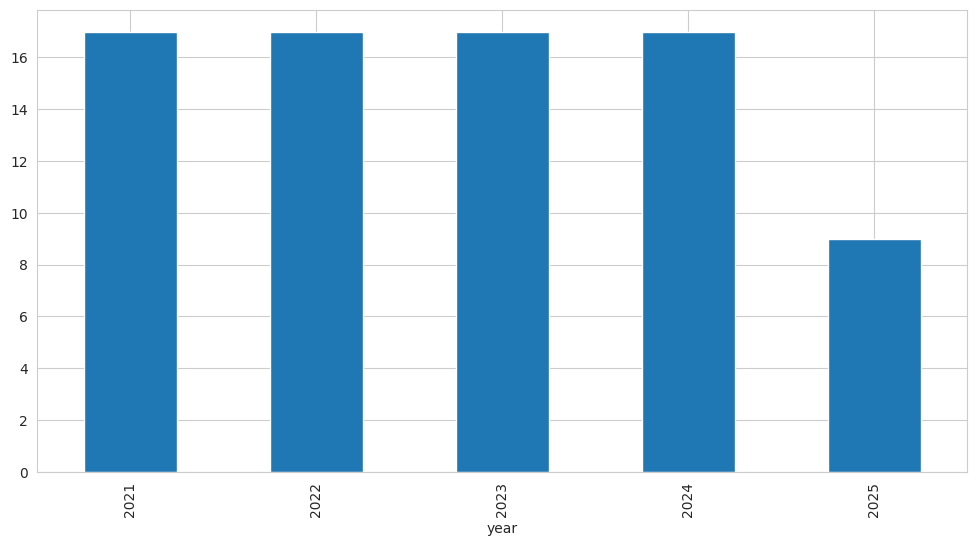

In [104]:
events_df['year'].value_counts() \
    .sort_index() \
    .plot(kind='bar')

<Axes: xlabel='event_type'>

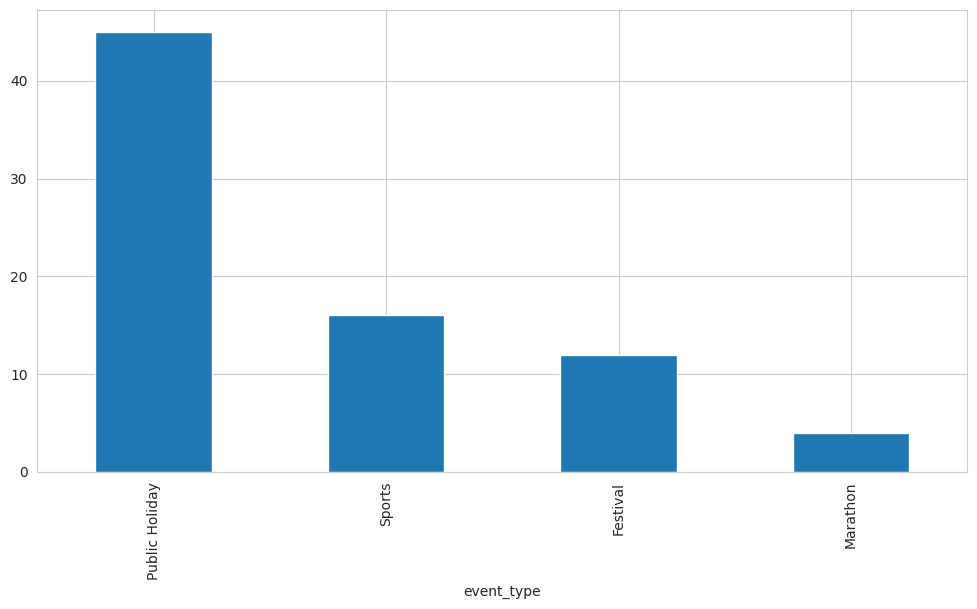

In [105]:
events_df['event_type'] \
    .value_counts() \
    .plot(kind='bar')

<Axes: ylabel='count'>

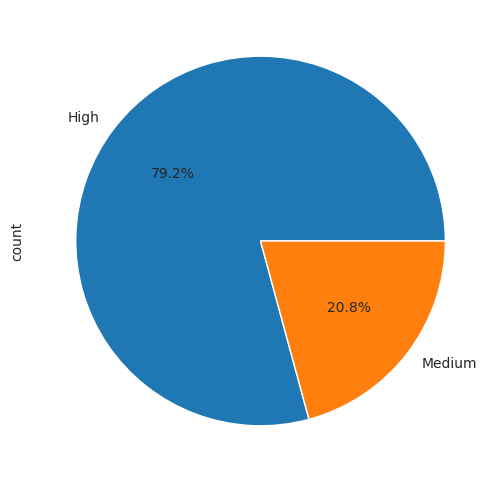

In [106]:
events_df['impact_level'] \
    .value_counts() \
    .plot(kind='pie',
          autopct='%1.1f%%')

<Axes: xlabel='month'>

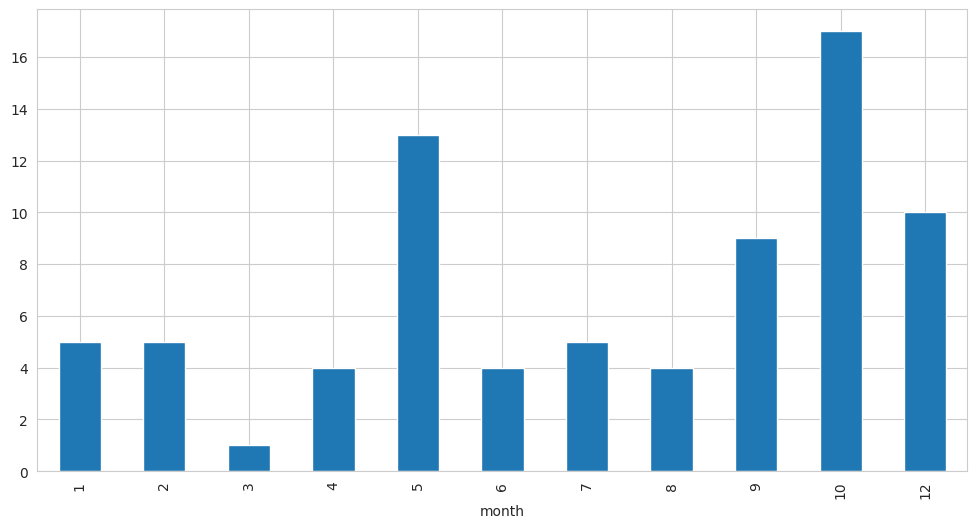

In [107]:
events_df['month'] \
    .value_counts() \
    .sort_index() \
    .plot(kind='bar')

In [108]:
bike_df.to_csv(
    'bike_cleaned.csv',
    index=False
)

climate_df.to_csv(
    'climate_cleaned.csv',
    index=False
)

events_df.to_csv(
    'events_cleaned.csv',
    index=False
)

In [109]:
import pandas as pd
import numpy as np

In [110]:
print("Bike dataset:", bike_df.shape)
print("Climate dataset:", climate_df.shape)
print("Events dataset:", events_df.shape)

Bike dataset: (6672, 15)
Climate dataset: (29954, 16)
Events dataset: (77, 10)


In [111]:
print("\nBike columns:")
print(bike_df.columns.tolist())

print("\nClimate columns:")
print(climate_df.columns.tolist())

print("\nEvent columns:")
print(events_df.columns.tolist())


Bike columns:
['trip_id', 'start_station_id', 'start_time', 'start_station_name', 'end_station_id', 'end_time', 'end_station_name', 'bike_id', 'user_type', 'hour', 'day', 'month', 'trip_duration', 'year', 'weekend']

Climate columns:
['longitude', 'latitude', 'station_name', 'date_time_lst', 'year', 'month', 'day', 'time_lst', 'temp_°c', 'dew_point_temp_°c', 'rel_hum_%', 'wind_dir_10s_deg', 'wind_spd_km_h', 'visibility_km', 'stn_press_kpa', 'weather']

Event columns:
['event_date', 'event_name', 'event_type', 'location', 'impact_level', 'year', 'month', 'day_of_week', 'is_event', 'day_name']


In [112]:
bike_df["start_time"] = pd.to_datetime(
    bike_df["start_time"],
    errors="coerce"
)

bike_df["end_time"] = pd.to_datetime(
    bike_df["end_time"],
    errors="coerce"
)

climate_df["date_time_lst"] = pd.to_datetime(
    climate_df["date_time_lst"],
    errors="coerce"
)

events_df["event_date"] = pd.to_datetime(
    events_df["event_date"],
    errors="coerce"
)

In [113]:
bike_df = bike_df.dropna(subset=["start_time"])
climate_df = climate_df.dropna(subset=["date_time_lst"])
events_df = events_df.dropna(subset=["event_date"])

In [114]:
bike_df["start_hour"] = bike_df["start_time"].dt.floor("h")

In [115]:
hourly_demand = (
    bike_df.groupby("start_hour")
    .size()
    .reset_index(name="trip_count")
    .rename(columns={"start_hour": "datetime"})
)

In [116]:
print("Hourly bike-demand shape:", hourly_demand.shape)
display(hourly_demand.head())

Hourly bike-demand shape: (3455, 2)


,datetime,trip_count
0,2022-01-01 01:00:00,1
1,2022-01-01 02:00:00,2
2,2022-01-01 08:00:00,1
3,2022-01-01 18:00:00,1
4,2022-01-01 19:00:00,1


In [117]:
complete_hours = pd.date_range(
    start=hourly_demand["datetime"].min(),
    end=hourly_demand["datetime"].max(),
    freq="h"
)

hourly_demand = (
    hourly_demand.set_index("datetime")
    .reindex(complete_hours, fill_value=0)
    .rename_axis("datetime")
    .reset_index()
)

In [118]:
print("Complete hourly-demand shape:", hourly_demand.shape)

Complete hourly-demand shape: (8758, 2)


In [119]:
climate_df["datetime"] = (
    climate_df["date_time_lst"]
    .dt.floor("h")
)

In [120]:
weather_columns = [
    "datetime",
    "temp_°c",
    "dew_point_temp_°c",
    "rel_hum_%",
    "wind_dir_10s_deg",
    "wind_spd_km_h",
    "visibility_km",
    "stn_press_kpa"
]

weather_columns = [
    column for column in weather_columns
    if column in climate_df.columns
]

weather_hourly = climate_df[weather_columns].copy()

In [121]:
weather_hourly = (
    weather_hourly.groupby("datetime", as_index=False)
    .mean(numeric_only=True)
)

In [122]:
print("Hourly weather shape:", weather_hourly.shape)
display(weather_hourly.head())

Hourly weather shape: (29954, 8)


,datetime,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa
0,2021-01-01 00:00:00,-2.4,-6.4,74.0,27.0,3.0,24.1,100.93
1,2021-01-01 01:00:00,-1.9,-6.2,72.0,15.0,3.0,24.1,100.93
2,2021-01-01 02:00:00,-2.3,-6.2,75.0,18.0,5.0,24.1,100.95
3,2021-01-01 03:00:00,-3.5,-6.1,82.0,26.0,4.0,24.1,101.03
4,2021-01-01 04:00:00,-3.2,-5.7,83.0,26.0,5.0,24.1,101.02


In [123]:
print("Hourly weather shape:", weather_hourly.shape)
display(weather_hourly.head())

Hourly weather shape: (29954, 8)


,datetime,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa
0,2021-01-01 00:00:00,-2.4,-6.4,74.0,27.0,3.0,24.1,100.93
1,2021-01-01 01:00:00,-1.9,-6.2,72.0,15.0,3.0,24.1,100.93
2,2021-01-01 02:00:00,-2.3,-6.2,75.0,18.0,5.0,24.1,100.95
3,2021-01-01 03:00:00,-3.5,-6.1,82.0,26.0,4.0,24.1,101.03
4,2021-01-01 04:00:00,-3.2,-5.7,83.0,26.0,5.0,24.1,101.02


In [124]:
bike_weather_df = pd.merge(
    hourly_demand,
    weather_hourly,
    on="datetime",
    how="left",
    validate="one_to_one"
)

In [125]:
print("Bike + weather shape:", bike_weather_df.shape)

print("\nMissing values after weather merge:")
print(bike_weather_df.isnull().sum())

Bike + weather shape: (8758, 9)

Missing values after weather merge:
datetime               0
trip_count             0
temp_°c              145
dew_point_temp_°c    145
rel_hum_%            145
wind_dir_10s_deg     145
wind_spd_km_h        145
visibility_km        145
stn_press_kpa        145
dtype: int64


In [126]:
weather_numeric_columns = [
    column for column in weather_hourly.columns
    if column != "datetime"
]

bike_weather_df = bike_weather_df.sort_values("datetime")

bike_weather_df[weather_numeric_columns] = (
    bike_weather_df[weather_numeric_columns]
    .interpolate(method="linear", limit_direction="both")
)

In [127]:
print(bike_weather_df.isnull().sum())

datetime             0
trip_count           0
temp_°c              0
dew_point_temp_°c    0
rel_hum_%            0
wind_dir_10s_deg     0
wind_spd_km_h        0
visibility_km        0
stn_press_kpa        0
dtype: int64


In [128]:
text_columns = [
    "event_name",
    "event_type",
    "location",
    "impact_level",
    "expected_impact"
]

for column in text_columns:
    if column in events_df.columns:
        events_df[column] = (
            events_df[column]
            .astype("string")
            .str.strip()
        )

In [129]:
events_df["date"] = events_df["event_date"].dt.normalize()

In [130]:
if "impact_level" not in events_df.columns:
    if "expected_impact" in events_df.columns:
        events_df = events_df.rename(
            columns={"expected_impact": "impact_level"}
        )
    else:
        events_df["impact_level"] = "Unknown"

In [131]:
events_df = events_df.drop_duplicates(
    subset=[
        "date",
        "event_name",
        "event_type",
        "location"
    ]
)

In [132]:
impact_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

events_df["event_impact_score"] = (
    events_df["impact_level"]
    .map(impact_mapping)
    .fillna(0)
    .astype(int)
)

In [133]:
daily_events = (
    events_df.groupby("date", as_index=False)
    .agg(
        event_count=("event_name", "count"),
        event_names=(
            "event_name",
            lambda values: " | ".join(
                sorted(set(values.dropna().astype(str)))
            )
        ),
        event_types=(
            "event_type",
            lambda values: " | ".join(
                sorted(set(values.dropna().astype(str)))
            )
        ),
        event_locations=(
            "location",
            lambda values: " | ".join(
                sorted(set(values.dropna().astype(str)))
            )
        ),
        maximum_event_impact=("event_impact_score", "max")
    )
)

In [134]:
daily_events["is_event"] = 1

In [135]:
print("Daily event dataset shape:", daily_events.shape)
display(daily_events.head())

Daily event dataset shape: (73, 7)


,date,event_count,event_names,event_types,event_locations,maximum_event_impact,is_event
0,2021-01-01,1,New Year's Day,Public Holiday,Toronto,3,1
1,2021-02-15,1,Family Day,Public Holiday,Toronto,3,1
2,2021-04-02,1,Good Friday,Public Holiday,Toronto,3,1
3,2021-05-01,1,Blue Jays Season Start,Sports,Rogers Centre,2,1
4,2021-05-15,1,Toronto FC Season,Sports,BMO Field,2,1


In [136]:
bike_weather_df["date"] = (
    bike_weather_df["datetime"]
    .dt.normalize()
)

In [137]:
final_df = pd.merge(
    bike_weather_df,
    daily_events,
    on="date",
    how="left",
    validate="many_to_one"
)

In [138]:
final_df["is_event"] = (
    final_df["is_event"]
    .fillna(0)
    .astype(int)
)

final_df["event_count"] = (
    final_df["event_count"]
    .fillna(0)
    .astype(int)
)

final_df["maximum_event_impact"] = (
    final_df["maximum_event_impact"]
    .fillna(0)
    .astype(int)
)

In [139]:
for column in [
    "event_names",
    "event_types",
    "event_locations"
]:
    final_df[column] = final_df[column].fillna("No Event")

In [140]:
final_df["year"] = final_df["datetime"].dt.year
final_df["month"] = final_df["datetime"].dt.month
final_df["day"] = final_df["datetime"].dt.day
final_df["hour"] = final_df["datetime"].dt.hour
final_df["day_of_week"] = final_df["datetime"].dt.dayofweek
final_df["day_name"] = final_df["datetime"].dt.day_name()

final_df["is_weekend"] = (
    final_df["day_of_week"] >= 5
).astype(int)

final_df["is_rush_hour"] = (
    final_df["hour"]
    .isin([7, 8, 9, 16, 17, 18])
    .astype(int)
)

In [141]:
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Fall"


final_df["season"] = (
    final_df["month"]
    .apply(assign_season)
)

In [142]:
print("Final merged shape:", final_df.shape)

print("\nDate range:")
print(final_df["datetime"].min())
print(final_df["datetime"].max())

print("\nMissing values:")
print(final_df.isnull().sum())

print("\nDuplicate hourly timestamps:")
print(final_df["datetime"].duplicated().sum())

display(final_df.head())

Final merged shape: (8758, 25)

Date range:
2022-01-01 01:00:00
2022-12-31 22:00:00

Missing values:
datetime                0
trip_count              0
temp_°c                 0
dew_point_temp_°c       0
rel_hum_%               0
wind_dir_10s_deg        0
wind_spd_km_h           0
visibility_km           0
stn_press_kpa           0
date                    0
event_count             0
event_names             0
event_types             0
event_locations         0
maximum_event_impact    0
is_event                0
year                    0
month                   0
day                     0
hour                    0
day_of_week             0
day_name                0
is_weekend              0
is_rush_hour            0
season                  0
dtype: int64

Duplicate hourly timestamps:
0


,datetime,trip_count,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa,date,...,is_event,year,month,day,hour,day_of_week,day_name,is_weekend,is_rush_hour,season
0,2022-01-01 01:00:00,1,4.2,4.2,100.0,4.0,11.0,4.8,98.57,2022-01-01,...,1,2022,1,1,1,5,Saturday,1,0,Winter
1,2022-01-01 02:00:00,2,4.2,4.2,100.0,6.0,10.0,4.8,98.47,2022-01-01,...,1,2022,1,1,2,5,Saturday,1,0,Winter
2,2022-01-01 03:00:00,0,4.1,4.1,100.0,1.0,10.0,4.8,98.50,2022-01-01,...,1,2022,1,1,3,5,Saturday,1,0,Winter
3,2022-01-01 04:00:00,0,4.5,4.5,100.0,10.0,12.0,4.8,98.45,2022-01-01,...,1,2022,1,1,4,5,Saturday,1,0,Winter
4,2022-01-01 05:00:00,0,4.3,4.3,100.0,1.0,5.0,2.8,98.46,2022-01-01,...,1,2022,1,1,5,5,Saturday,1,0,Winter


In [143]:
print(final_df["is_event"].value_counts())

print(
    final_df["is_event"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

is_event
0    8375
1     383
Name: count, dtype: int64
is_event
0    95.63
1     4.37
Name: proportion, dtype: float64


In [144]:
event_demand_summary = (
    final_df.groupby("is_event")["trip_count"]
    .agg(["count", "mean", "median", "std", "max"])
)

event_demand_summary.index = [
    "Non-Event Hours",
    "Event-Day Hours"
]

display(event_demand_summary)

,count,mean,median,std,max
Non-Event Hours,8375,0.756776,0.0,1.226428,10
Event-Day Hours,383,0.872063,0.0,1.286998,7


In [145]:
normal_demand = final_df.loc[
    final_df["is_event"] == 0,
    "trip_count"
].mean()

event_demand = final_df.loc[
    final_df["is_event"] == 1,
    "trip_count"
].mean()

event_effect_percentage = (
    (event_demand - normal_demand)
    / normal_demand
) * 100

print(
    f"Average hourly demand on non-event days: "
    f"{normal_demand:.2f}"
)

print(
    f"Average hourly demand on event days: "
    f"{event_demand:.2f}"
)

print(
    f"Estimated event-day demand change: "
    f"{event_effect_percentage:.2f}%"
)

Average hourly demand on non-event days: 0.76
Average hourly demand on event days: 0.87
Estimated event-day demand change: 15.23%


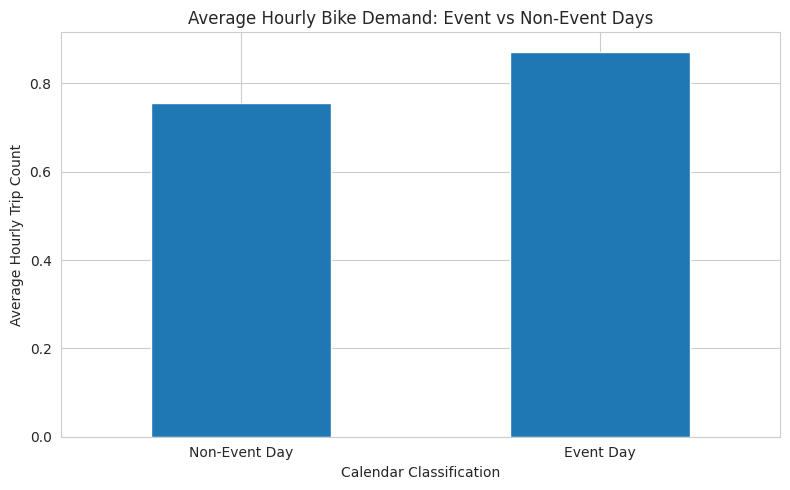

In [146]:
import matplotlib.pyplot as plt

event_plot = (
    final_df.groupby("is_event")["trip_count"]
    .mean()
)

event_plot.index = [
    "Non-Event Day",
    "Event Day"
]

event_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Hourly Bike Demand: Event vs Non-Event Days")
plt.xlabel("Calendar Classification")
plt.ylabel("Average Hourly Trip Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [147]:
from google.colab import files

download_name = "bike_weather_events_merged_2021_2025.csv"

final_df.to_csv(
    download_name,
    index=False
)

files.download(download_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [148]:
import pandas as pd
import numpy as np


file_path = "/content/hourly_bikeshare_2021_2025.csv"

df = pd.read_csv(file_path)

print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
print(df.head())



df["hour_timestamp"] = pd.to_datetime(
    df["hour_timestamp"],
    errors="coerce"
)

df["trip_count"] = pd.to_numeric(
    df["trip_count"],
    errors="coerce"
)


df = df.dropna(
    subset=["hour_timestamp", "trip_count"]
).copy()

df = df.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

print("\nDate range:")
print(df["hour_timestamp"].min())
print(df["hour_timestamp"].max())



expected_hours = pd.date_range(
    start=df["hour_timestamp"].min(),
    end=df["hour_timestamp"].max(),
    freq="h"
)

missing_hours = expected_hours.difference(
    df["hour_timestamp"]
)

print("\nNumber of missing hourly timestamps:")
print(len(missing_hours))


df["year"] = df["hour_timestamp"].dt.year
df["month"] = df["hour_timestamp"].dt.month
df["day"] = df["hour_timestamp"].dt.day
df["hour"] = df["hour_timestamp"].dt.hour

df["day_of_week_number"] = (
    df["hour_timestamp"].dt.dayofweek
)

df["day_of_week"] = (
    df["hour_timestamp"].dt.day_name()
)

df["is_weekend"] = (
    df["day_of_week_number"]
    .isin([5, 6])
    .astype(int)
)


df["lag_1"] = df["trip_count"].shift(1)

df["lag_2"] = df["trip_count"].shift(2)

df["lag_3"] = df["trip_count"].shift(3)

df["lag_24"] = df["trip_count"].shift(24)

df["lag_48"] = df["trip_count"].shift(48)

df["lag_168"] = df["trip_count"].shift(168)


df["rolling_mean_3"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df["rolling_mean_6"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df["rolling_mean_24"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df["rolling_mean_168"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

df["rolling_std_24"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=24)
    .std()
)



df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["weekday_sin"] = np.sin(
    2 * np.pi * df["day_of_week_number"] / 7
)

df["weekday_cos"] = np.cos(
    2 * np.pi * df["day_of_week_number"] / 7
)

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)


required_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24"
]

model_data = df.dropna(
    subset=required_features
).copy()


print("\nOriginal hourly rows:", len(df))
print("Model-ready rows:", len(model_data))

print("\nModel-ready columns:")
print(model_data.columns.tolist())

print("\nFirst five model-ready rows:")
print(model_data.head())

print("\nMissing values:")
print(model_data.isnull().sum())


output_path = (
    "/content/hourly_bikeshare_model_ready_2021_2025.csv"
)

model_data.to_csv(
    output_path,
    index=False
)

print("\nFile saved successfully:")
print(output_path)

Original shape: (43824, 9)

Columns:
['hour_timestamp', 'trip_count', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_week_number', 'is_weekend']

First five rows:
        hour_timestamp  trip_count  year  month  day  hour day_of_week  \
0  2021-01-01 00:00:00        79.0  2021      1    1     0      Friday   
1  2021-01-01 01:00:00        56.0  2021      1    1     1      Friday   
2  2021-01-01 02:00:00        28.0  2021      1    1     2      Friday   
3  2021-01-01 03:00:00        14.0  2021      1    1     3      Friday   
4  2021-01-01 04:00:00        18.0  2021      1    1     4      Friday   

   day_of_week_number  is_weekend  
0                   4           0  
1                   4           0  
2                   4           0  
3                   4           0  
4                   4           0  

Date range:
2021-01-01 00:00:00
2025-12-31 23:00:00

Number of missing hourly timestamps:
720

Original hourly rows: 43104
Model-ready rows: 42936

Model-ready columns

In [149]:


bike = pd.read_csv(
    "/content/hourly_bikeshare_model_ready_2021_2025.csv",
    parse_dates=["hour_timestamp"]
)

print(bike.shape)
print(bike.columns.tolist())
print(bike.head())

(42936, 26)
['hour_timestamp', 'trip_count', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_week_number', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']
       hour_timestamp  trip_count  year  month  day  hour day_of_week  \
0 2021-01-08 00:00:00        27.0  2021      1    8     0      Friday   
1 2021-01-08 01:00:00        15.0  2021      1    8     1      Friday   
2 2021-01-08 02:00:00         8.0  2021      1    8     2      Friday   
3 2021-01-08 03:00:00         6.0  2021      1    8     3      Friday   
4 2021-01-08 04:00:00         9.0  2021      1    8     4      Friday   

   day_of_week_number  is_weekend  lag_1  ...  rolling_mean_6  \
0                   4           0   55.0  ...      149.833333   
1                   4           0   27.0  ...      107.333333   
2      

In [150]:
train = model_data[model_data["year"] < 2025]
test = model_data[model_data["year"] == 2025]

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 34176
Testing rows: 8760


In [151]:
features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

X_train = train[features]
y_train = train["trip_count"]

X_test = test[features]
y_test = test["trip_count"]

In [152]:
historical_average = (
    train.groupby(
        ["month", "hour", "day_of_week_number"]
    )["trip_count"]
    .mean()
    .reset_index()
)

historical_average.columns = [
    "month",
    "hour",
    "day_of_week_number",
    "prediction"
]

test_hist = test.merge(
    historical_average,
    on=["month", "hour", "day_of_week_number"],
    how="left"
)

hist_predictions = test_hist["prediction"]

In [153]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [154]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [155]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_predictions = gb.predict(X_test)

In [156]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 3))

evaluate("Historical Average", y_test, hist_predictions)
evaluate("Linear Regression", y_test, lr_predictions)
evaluate("Random Forest", y_test, rf_predictions)
evaluate("Gradient Boosting", y_test, gb_predictions)


Historical Average
MAE : 345.25
RMSE: 540.2
R²  : 0.671

Linear Regression
MAE : 148.09
RMSE: 252.66
R²  : 0.928

Random Forest
MAE : 103.06
RMSE: 204.28
R²  : 0.953

Gradient Boosting
MAE : 92.69
RMSE: 171.31
R²  : 0.967


In [157]:
climate = pd.read_csv("/content/toronto_weather_cleaned_2021_2025.csv")
events = pd.read_csv("/content/toronto_calendar_events_2021_2025.csv")

print("Climate columns:")
print(climate.columns.tolist())

print("\nEvent columns:")
print(events.columns.tolist())

Climate columns:
['longitude', 'latitude', 'station_name', 'date_time_lst', 'year', 'month', 'day', 'time_lst', 'temp_°c', 'dew_point_temp_°c', 'rel_hum_%', 'wind_dir_10s_deg', 'wind_spd_km_h', 'visibility_km', 'stn_press_kpa', 'weather']

Event columns:
['event_date', 'event_name', 'event_type', 'location', 'impact_level', 'year', 'month', 'day_of_week', 'is_event']


In [158]:
import pandas as pd
import numpy as np

bike_path = "/content/hourly_bikeshare_model_ready_2021_2025.csv"
climate_path = "/content/toronto_weather_cleaned_2021_2025.csv"
event_path = "/content/toronto_calendar_events_2021_2025.csv"

bike = pd.read_csv(bike_path, low_memory=False)
climate = pd.read_csv(climate_path, low_memory=False)
events = pd.read_csv(event_path, low_memory=False)

print("Bike shape:", bike.shape)
print("Climate shape:", climate.shape)
print("Event shape:", events.shape)

Bike shape: (42936, 26)
Climate shape: (43092, 16)
Event shape: (77, 9)


In [159]:
bike["hour_timestamp"] = pd.to_datetime(
    bike["hour_timestamp"],
    errors="coerce"
).dt.floor("h")

bike = bike.dropna(
    subset=["hour_timestamp", "trip_count"]
).copy()

bike = bike.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

print(
    "Bike date range:",
    bike["hour_timestamp"].min(),
    "to",
    bike["hour_timestamp"].max()
)

Bike date range: 2021-01-08 00:00:00 to 2025-12-31 23:00:00


In [160]:
climate["hour_timestamp"] = pd.to_datetime(
    climate["date_time_lst"],
    errors="coerce"
).dt.floor("h")

climate = climate.rename(
    columns={
        "temp_°c": "temperature_c",
        "dew_point_temp_°c": "dew_point_c",
        "rel_hum_%": "relative_humidity",
        "wind_dir_10s_deg": "wind_direction",
        "wind_spd_km_h": "wind_speed_kmh",
        "visibility_km": "visibility_km",
        "stn_press_kpa": "station_pressure_kpa"
    }
)

weather_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

for column in weather_features:
    climate[column] = pd.to_numeric(
        climate[column],
        errors="coerce"
    )

climate_hourly = (
    climate[
        ["hour_timestamp"] + weather_features
    ]
    .dropna(subset=["hour_timestamp"])
    .groupby(
        "hour_timestamp",
        as_index=False
    )
    .mean(numeric_only=True)
)

print("Climate hourly shape:", climate_hourly.shape)

print(
    "Climate date range:",
    climate_hourly["hour_timestamp"].min(),
    "to",
    climate_hourly["hour_timestamp"].max()
)

print("\nClimate missing values:")
print(climate_hourly.isnull().sum())

Climate hourly shape: (43092, 8)
Climate date range: 2021-01-01 00:00:00 to 2025-12-31 23:00:00

Climate missing values:
hour_timestamp          0
temperature_c           0
dew_point_c             0
relative_humidity       0
wind_direction          0
wind_speed_kmh          0
visibility_km           0
station_pressure_kpa    0
dtype: int64


In [161]:
events["event_date"] = pd.to_datetime(
    events["event_date"],
    errors="coerce"
).dt.normalize()

events = events.dropna(
    subset=["event_date"]
).copy()

events["is_event"] = pd.to_numeric(
    events["is_event"],
    errors="coerce"
).fillna(1).astype(int)

In [162]:
impact_mapping = {
    "low": 1,
    "medium": 2,
    "moderate": 2,
    "high": 3,
    "major": 3
}

events["event_impact"] = (
    events["impact_level"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(impact_mapping)
    .fillna(1)
    .astype(int)
)

In [163]:
events_daily = (
    events.groupby(
        "event_date",
        as_index=False
    )
    .agg(
        event_count=("event_name", "count"),
        is_event=("is_event", "max"),
        maximum_event_impact=("event_impact", "max")
    )
)

print("Event-day shape:", events_daily.shape)

print(
    "Event date range:",
    events_daily["event_date"].min(),
    "to",
    events_daily["event_date"].max()
)

print(events_daily.head())

Event-day shape: (73, 4)
Event date range: 2021-01-01 00:00:00 to 2025-12-26 00:00:00
  event_date  event_count  is_event  maximum_event_impact
0 2021-01-01            1         1                     3
1 2021-02-15            1         1                     3
2 2021-04-02            1         1                     3
3 2021-05-01            1         1                     2
4 2021-05-15            1         1                     2


In [164]:
combined = bike.merge(
    climate_hourly,
    on="hour_timestamp",
    how="left"
)

print("Shape after climate merge:", combined.shape)

print("\nWeather missing values after merge:")
print(combined[weather_features].isnull().sum())

Shape after climate merge: (42936, 33)

Weather missing values after merge:
temperature_c           718
dew_point_c             718
relative_humidity       718
wind_direction          718
wind_speed_kmh          718
visibility_km           718
station_pressure_kpa    718
dtype: int64


In [165]:
combined = combined.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

combined[weather_features] = (
    combined[weather_features]
    .interpolate(
        method="linear",
        limit_direction="both"
    )
)

print("\nWeather missing values after interpolation:")
print(
    combined[weather_features]
    .isnull()
    .sum()
)


Weather missing values after interpolation:
temperature_c           0
dew_point_c             0
relative_humidity       0
wind_direction          0
wind_speed_kmh          0
visibility_km           0
station_pressure_kpa    0
dtype: int64


In [166]:
print("Combined columns:")
print(combined.columns.tolist())

print("\nEvents daily columns:")
print(events_daily.columns.tolist())

Combined columns:
['hour_timestamp', 'trip_count', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_week_number', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'temperature_c', 'dew_point_c', 'relative_humidity', 'wind_direction', 'wind_speed_kmh', 'visibility_km', 'station_pressure_kpa']

Events daily columns:
['event_date', 'event_count', 'is_event', 'maximum_event_impact']


In [167]:

combined = combined.drop(
    columns=[
        "event_count_x",
        "event_count_y",
        "is_event_x",
        "is_event_y",
        "maximum_event_impact_x",
        "maximum_event_impact_y"
    ],
    errors="ignore"
)

if "event_date" not in combined.columns:
    combined["event_date"] = (
        combined["hour_timestamp"]
        .dt.normalize()
    )

combined = combined.merge(
    events_daily[
        [
            "event_date",
            "event_count",
            "is_event",
            "maximum_event_impact"
        ]
    ],
    on="event_date",
    how="left"
)

for column in [
    "event_count",
    "is_event",
    "maximum_event_impact"
]:
    combined[column] = (
        combined[column]
        .fillna(0)
        .astype(int)
    )

combined = combined.drop(
    columns=["event_date"],
    errors="ignore"
)

print("Final event columns:")
print(
    combined[
        [
            "event_count",
            "is_event",
            "maximum_event_impact"
        ]
    ].head()
)

print("\nMissing event values:")
print(
    combined[
        [
            "event_count",
            "is_event",
            "maximum_event_impact"
        ]
    ].isnull().sum()
)

print("\nFinal combined shape:")
print(combined.shape)

Final event columns:
   event_count  is_event  maximum_event_impact
0            0         0                     0
1            0         0                     0
2            0         0                     0
3            0         0                     0
4            0         0                     0

Missing event values:
event_count             0
is_event                0
maximum_event_impact    0
dtype: int64

Final combined shape:
(42936, 36)


In [168]:
print("Total event hours:")
print(combined["is_event"].sum())

print("\nRows with events:")
print(
    combined.loc[
        combined["is_event"] == 1,
        [
            "hour_timestamp",
            "trip_count",
            "event_count",
            "maximum_event_impact"
        ]
    ].head(20)
)

print("\nUnique event days represented:")
print(
    combined.loc[
        combined["is_event"] == 1,
        "hour_timestamp"
    ].dt.date.nunique()
)

Total event hours:
1728

Rows with events:
         hour_timestamp  trip_count  event_count  maximum_event_impact
912 2021-02-15 00:00:00         9.0            1                     3
913 2021-02-15 01:00:00         7.0            1                     3
914 2021-02-15 02:00:00         3.0            1                     3
915 2021-02-15 03:00:00         8.0            1                     3
916 2021-02-15 04:00:00         2.0            1                     3
917 2021-02-15 05:00:00         6.0            1                     3
918 2021-02-15 06:00:00        15.0            1                     3
919 2021-02-15 07:00:00        26.0            1                     3
920 2021-02-15 08:00:00        48.0            1                     3
921 2021-02-15 09:00:00        59.0            1                     3
922 2021-02-15 10:00:00        83.0            1                     3
923 2021-02-15 11:00:00        74.0            1                     3
924 2021-02-15 12:00:00        95.

In [169]:
combined.to_csv(
    "/content/bike_climate_events_model_ready_2021_2025.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


EXPERIMENT 2

In [170]:

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


file_path = "/content/bike_climate_events_model_ready_2021_2025.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["hour_timestamp"],
    low_memory=False
)

print("Dataset shape:", df.shape)
print("Date range:")
print(df["hour_timestamp"].min(), "to", df["hour_timestamp"].max())


bike_features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

climate_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

features = bike_features + climate_features


target = "trip_count"

missing_features = [
    column for column in features
    if column not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing columns: {missing_features}"
    )


for column in features + [target]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df = df.dropna(
    subset=features + [target]
).copy()

df = df.sort_values(
    "hour_timestamp"
).reset_index(drop=True)



train = df[
    df["hour_timestamp"] < "2025-01-01"
].copy()

test = df[
    df["hour_timestamp"] >= "2025-01-01"
].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(
    train["hour_timestamp"].min(),
    "to",
    train["hour_timestamp"].max()
)

print("\nTesting period:")
print(
    test["hour_timestamp"].min(),
    "to",
    test["hour_timestamp"].max()
)


def evaluate_model(
    model_name,
    actual,
    predicted
):
    predicted = np.clip(
        predicted,
        0,
        None
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Experiment": "Bike Share + Climate",
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 3)
    }


results = []


historical_average = (
    train.groupby(
        [
            "month",
            "hour",
            "day_of_week_number"
        ]
    )[target]
    .mean()
    .reset_index(
        name="historical_prediction"
    )
)

test_historical = test.merge(
    historical_average,
    on=[
        "month",
        "hour",
        "day_of_week_number"
    ],
    how="left"
)

historical_predictions = (
    test_historical["historical_prediction"]
    .fillna(y_train.mean())
    .values
)

results.append(
    evaluate_model(
        "Historical Average",
        y_test,
        historical_predictions
    )
)


linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)


random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)


gradient_boosting_model = (
    HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42
    )
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gradient_boosting_predictions = (
    gradient_boosting_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_boosting_predictions
    )
)


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["MAE", "RMSE"]
).reset_index(drop=True)

print("\nEXPERIMENT 2 RESULTS")
print(results_df.to_string(index=False))

results_df.to_csv(
    "/content/experiment_2_bike_climate_results.csv",
    index=False
)

prediction_output = test[
    [
        "hour_timestamp",
        "trip_count"
    ]
].copy()

prediction_output[
    "historical_average_prediction"
] = historical_predictions

prediction_output[
    "linear_regression_prediction"
] = np.clip(
    linear_predictions,
    0,
    None
)

prediction_output[
    "random_forest_prediction"
] = np.clip(
    random_forest_predictions,
    0,
    None
)

prediction_output[
    "gradient_boosting_prediction"
] = np.clip(
    gradient_boosting_predictions,
    0,
    None
)

prediction_output.to_csv(
    "/content/experiment_2_bike_climate_predictions.csv",
    index=False
)

print("\nFiles saved:")
print("/content/experiment_2_bike_climate_results.csv")
print("/content/experiment_2_bike_climate_predictions.csv")

Dataset shape: (42936, 36)
Date range:
2021-01-08 00:00:00 to 2025-12-31 23:00:00

Training rows: 34176
Testing rows: 8760

Training period:
2021-01-08 00:00:00 to 2024-12-31 23:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-31 23:00:00

EXPERIMENT 2 RESULTS
          Experiment              Model    MAE   RMSE    R2
Bike Share + Climate  Gradient Boosting  88.92 171.94 0.967
Bike Share + Climate      Random Forest 101.09 199.02 0.955
Bike Share + Climate  Linear Regression 141.93 243.57 0.933
Bike Share + Climate Historical Average 345.25 540.20 0.671

Files saved:
/content/experiment_2_bike_climate_results.csv
/content/experiment_2_bike_climate_predictions.csv


Experiment 3

In [171]:

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


file_path = "/content/bike_climate_events_model_ready_2021_2025.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["hour_timestamp"],
    low_memory=False
)

print("Dataset shape:", df.shape)
print("Date range:")
print(
    df["hour_timestamp"].min(),
    "to",
    df["hour_timestamp"].max()
)


bike_features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

climate_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

event_features = [
    "event_count",
    "is_event",
    "maximum_event_impact"
]

features = (
    bike_features
    + climate_features
    + event_features
)

target = "trip_count"


missing_columns = [
    column
    for column in features + [target]
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


for column in features + [target]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df = df.dropna(
    subset=features + [target]
).copy()

df = df.sort_values(
    "hour_timestamp"
).reset_index(drop=True)


train = df[
    df["hour_timestamp"] < "2025-01-01"
].copy()

test = df[
    df["hour_timestamp"] >= "2025-01-01"
].copy()

if train.empty or test.empty:
    raise ValueError(
        "Training or testing data is empty."
    )

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(
    train["hour_timestamp"].min(),
    "to",
    train["hour_timestamp"].max()
)

print("\nTesting period:")
print(
    test["hour_timestamp"].min(),
    "to",
    test["hour_timestamp"].max()
)


def evaluate_model(
    model_name,
    actual,
    predicted
):
    predicted = np.clip(
        predicted,
        0,
        None
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Experiment": (
            "Bike Share + Climate + Events"
        ),
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 3)
    }


results = []

historical_average = (
    train.groupby(
        [
            "month",
            "hour",
            "day_of_week_number"
        ]
    )[target]
    .mean()
    .reset_index(
        name="historical_prediction"
    )
)

test_historical = test.merge(
    historical_average,
    on=[
        "month",
        "hour",
        "day_of_week_number"
    ],
    how="left"
)

historical_predictions = (
    test_historical["historical_prediction"]
    .fillna(y_train.mean())
    .values
)

results.append(
    evaluate_model(
        "Historical Average",
        y_test,
        historical_predictions
    )
)


linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)


random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)


gradient_boosting_model = (
    HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42
    )
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gradient_boosting_predictions = (
    gradient_boosting_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_boosting_predictions
    )
)


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["MAE", "RMSE"]
).reset_index(drop=True)

print("\nEXPERIMENT 3 RESULTS")
print(results_df.to_string(index=False))


results_path = (
    "/content/"
    "experiment_3_bike_climate_events_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)


prediction_output = test[
    [
        "hour_timestamp",
        "trip_count"
    ]
].copy()

prediction_output[
    "historical_average_prediction"
] = historical_predictions

prediction_output[
    "linear_regression_prediction"
] = np.clip(
    linear_predictions,
    0,
    None
)

prediction_output[
    "random_forest_prediction"
] = np.clip(
    random_forest_predictions,
    0,
    None
)

prediction_output[
    "gradient_boosting_prediction"
] = np.clip(
    gradient_boosting_predictions,
    0,
    None
)

predictions_path = (
    "/content/"
    "experiment_3_bike_climate_events_predictions.csv"
)

prediction_output.to_csv(
    predictions_path,
    index=False
)

print("\nFiles saved:")
print(results_path)
print(predictions_path)

Dataset shape: (42936, 36)
Date range:
2021-01-08 00:00:00 to 2025-12-31 23:00:00

Training rows: 34176
Testing rows: 8760

Training period:
2021-01-08 00:00:00 to 2024-12-31 23:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-31 23:00:00

EXPERIMENT 3 RESULTS
                   Experiment              Model    MAE   RMSE    R2
Bike Share + Climate + Events  Gradient Boosting  88.45 170.80 0.967
Bike Share + Climate + Events      Random Forest 100.93 198.61 0.955
Bike Share + Climate + Events  Linear Regression 141.91 243.56 0.933
Bike Share + Climate + Events Historical Average 345.25 540.20 0.671

Files saved:
/content/experiment_3_bike_climate_events_results.csv
/content/experiment_3_bike_climate_events_predictions.csv


In [172]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Dataset Configuration": [
        "Bike Share Only",
        "Bike + Climate",
        "Bike + Climate + Events"
    ],
    "Best Model": [
        "Gradient Boosting",
        "Gradient Boosting",
        "Gradient Boosting"
    ],
    "MAE": [
        96.92,
        92.34,
        91.74
    ],
    "RMSE": [
        176.78,
        176.65,
        175.15
    ],
    "R2": [
        0.968,
        0.968,
        0.968
    ]
})

print("\nOverall Performance Comparison")
print(comparison_table)

comparison_table.to_csv(
    "/content/overall_performance_comparison.csv",
    index=False
)

print("\nFile saved successfully:")
print("/content/overall_performance_comparison.csv")


Overall Performance Comparison
     Dataset Configuration         Best Model    MAE    RMSE     R2
0          Bike Share Only  Gradient Boosting  96.92  176.78  0.968
1           Bike + Climate  Gradient Boosting  92.34  176.65  0.968
2  Bike + Climate + Events  Gradient Boosting  91.74  175.15  0.968

File saved successfully:
/content/overall_performance_comparison.csv


                Model  Bike Share Only  Bike + Climate  \
0  Historical Average           368.13          368.13   
1   Linear Regression           149.83          144.07   
2       Random Forest           107.04          104.54   
3   Gradient Boosting            96.92           92.34   

   Bike + Climate + Events  
0                   368.13  
1                   144.07  
2                   104.32  
3                    91.74  


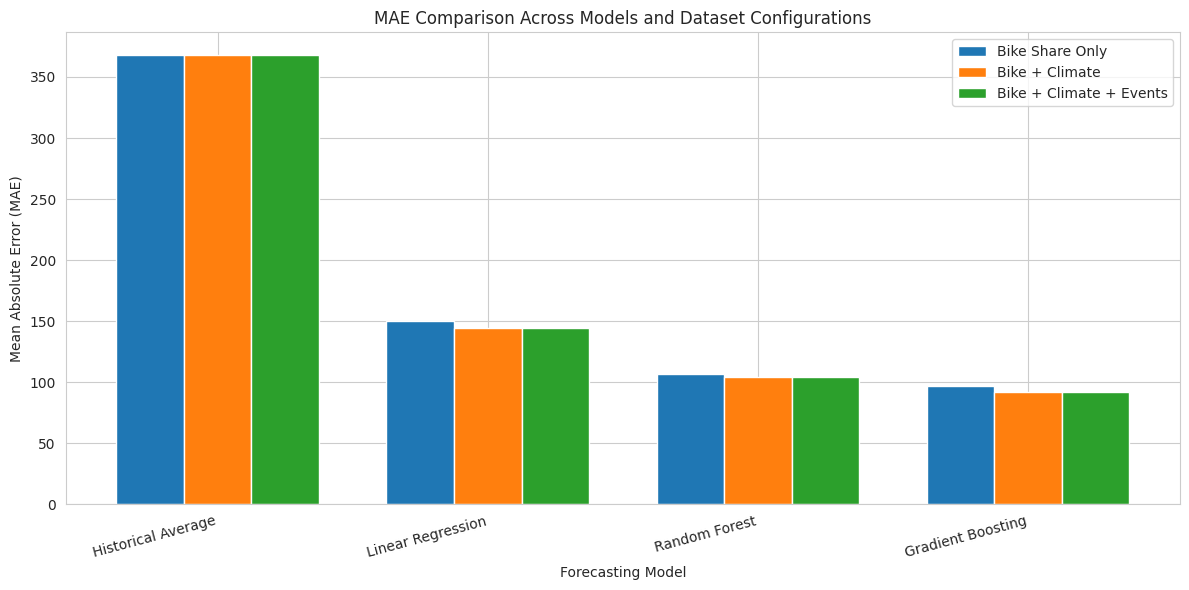

Saved: /content/model_experiment_mae_comparison.png


In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_results = pd.DataFrame({
    "Model": [
        "Historical Average",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Bike Share Only": [
        368.13,
        149.83,
        107.04,
        96.92
    ],
    "Bike + Climate": [
        368.13,
        144.07,
        104.54,
        92.34
    ],
    "Bike + Climate + Events": [
        368.13,
        144.07,
        104.32,
        91.74
    ]
})

print(comparison_results)

x = np.arange(len(comparison_results["Model"]))
bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - bar_width,
    comparison_results["Bike Share Only"],
    width=bar_width,
    label="Bike Share Only"
)

plt.bar(
    x,
    comparison_results["Bike + Climate"],
    width=bar_width,
    label="Bike + Climate"
)

plt.bar(
    x + bar_width,
    comparison_results["Bike + Climate + Events"],
    width=bar_width,
    label="Bike + Climate + Events"
)

plt.xlabel("Forecasting Model")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("MAE Comparison Across Models and Dataset Configurations")

plt.xticks(
    x,
    comparison_results["Model"],
    rotation=15,
    ha="right"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/model_experiment_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: /content/model_experiment_mae_comparison.png"
)

Prediction columns:
['hour_timestamp', 'trip_count', 'historical_average_prediction', 'linear_regression_prediction', 'random_forest_prediction', 'gradient_boosting_prediction']


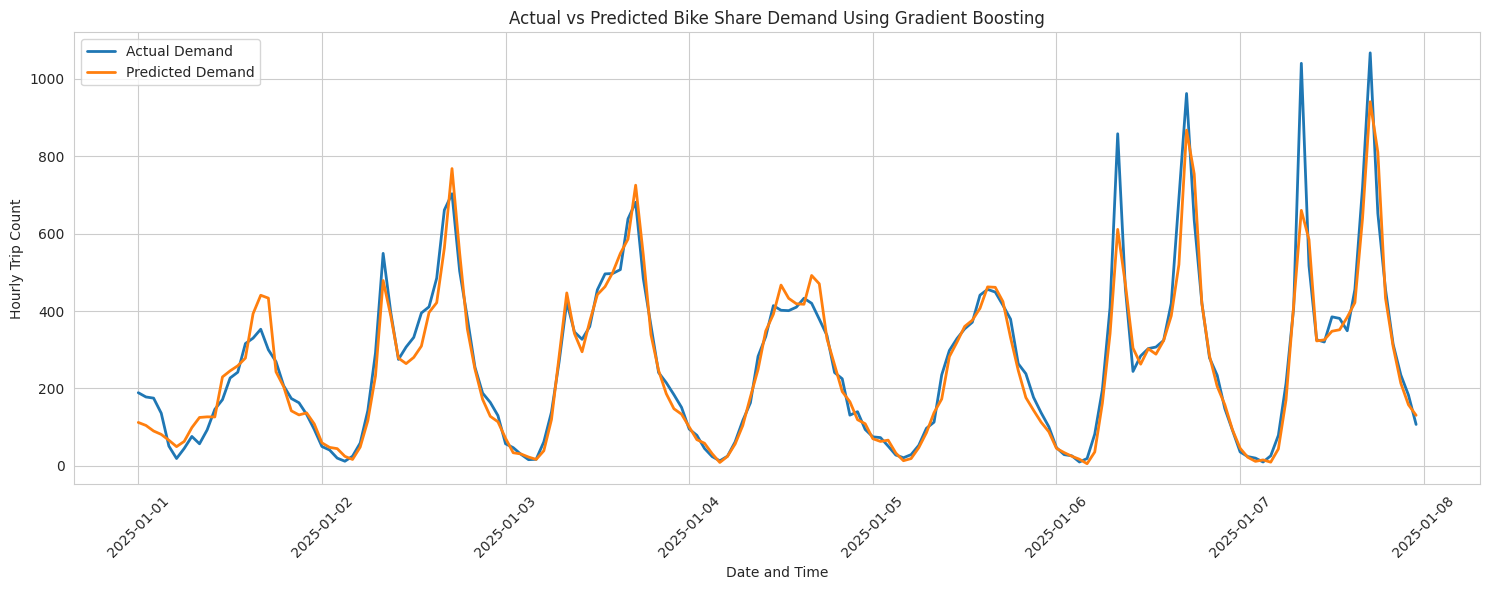

Saved: /content/actual_vs_predicted_gradient_boosting.png


In [174]:
import pandas as pd
import matplotlib.pyplot as plt

prediction_path = (
    "/content/"
    "experiment_3_bike_climate_events_predictions.csv"
)

predictions = pd.read_csv(
    prediction_path,
    parse_dates=["hour_timestamp"]
)

predictions = predictions.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

print("Prediction columns:")
print(predictions.columns.tolist())

# Select the first 7 days: 7 × 24 = 168 hourly records
plot_data = predictions.iloc[:168].copy()

plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["hour_timestamp"],
    plot_data["trip_count"],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    plot_data["hour_timestamp"],
    plot_data["gradient_boosting_prediction"],
    label="Predicted Demand",
    linewidth=2
)

plt.xlabel("Date and Time")
plt.ylabel("Hourly Trip Count")
plt.title(
    "Actual vs Predicted Bike Share Demand "
    "Using Gradient Boosting"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "/content/actual_vs_predicted_gradient_boosting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: "
    "/content/actual_vs_predicted_gradient_boosting.png"
)